In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show
from matplotlib import rcParams
from matplotlib.patches import Patch
import scienceplots

In [2]:
rcParams['xtick.direction'] = 'in'         # ticks pointing inward (standard in astronomy)
rcParams['ytick.direction'] = 'in'
rcParams['xtick.top'] = True               # mirror ticks on top
rcParams['ytick.right'] = True
rcParams['xtick.major.size'] = 5
rcParams['xtick.minor.size'] = 3
rcParams['xtick.minor.visible'] = True
rcParams['ytick.minor.visible'] = True

rcParams['axes.linewidth'] = 2
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.8
rcParams['grid.linestyle'] = '-'

rcParams['font.family'] = 'serif'          # or 'sans-serif' (Nature/AAS style)
rcParams['font.serif'] = ['Times New Roman']
rcParams['font.size'] = 16
rcParams['axes.labelsize'] = 22            # axis label size
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['text.usetex'] = True             # render labels with LaTeX

plt.style.use(['science', 'no-latex'])

In [3]:
# import N_obs from supertable_code.py and the corresponding Case # and Planet
exec(open("supertable_code.py").read())

#phase curve
N_obs = df['N_obs']
Case = df['Case #']
Planet = df['Planet']
Time = df["T_obs [hours]"]

#eclipse stacking
N_day = df['N_day']
T_day = df["T_day [hours]"]

# daynight contrast
N_pc = df['N_pc']
T_pc = df["T_pc [hours]"]

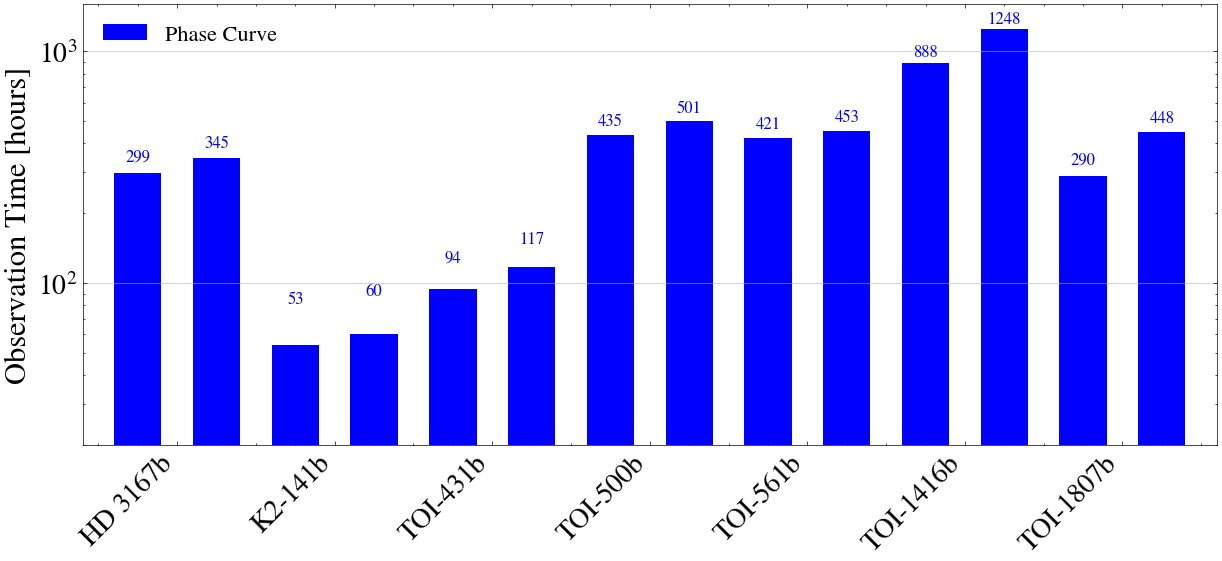

In [12]:
# group bars by planet, in a fixed planet order, sorted by Time within each planet (same ordering as the grouped plots)
planet_order = ["HD 3167b", "K2-141b", "TOI-431b", "TOI-500b", "TOI-561b", "TOI-1416b", "TOI-1807b"]
planet_rank = Planet.map({p: i for i, p in enumerate(planet_order)})
composite = planet_rank.values * 10000 + Time.values
order = np.argsort(composite)
mask = (N_obs < 1000) & (N_obs > 0) # filter out N_obs = 0

N_obs_sorted = N_obs.iloc[order].loc[mask]
Case_sorted = Case.iloc[order].loc[mask]
Planet_sorted = Planet.iloc[order].loc[mask]
Time_sorted = Time.iloc[order].loc[mask]

n_bars = len(Planet_sorted)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * n_bars), 6))
plt.grid(False); plt.grid(True, axis='y')

ax.bar(range(n_bars), Time_sorted, color="blue", width=0.6,alpha=1)

legend_elements = [Patch(facecolor="blue", label="Phase Curve")]
ax.legend(handles=legend_elements)

# write the observation count on top of each bar, in the bar's color
y_offset = 0.02 * max(Time_sorted)
for i, (t, n) in enumerate(zip(Time_sorted, N_obs_sorted)):
    ax.text(i, t + y_offset, f"{int(t)}", rotation=0, ha="center", va="bottom", color="blue", fontsize=12)

# one planet label centered between the bars of each group, instead of one label per bar
group_ticks, group_labels = [], []
start = 0
for i in range(1, n_bars + 1):
    if i == n_bars or Planet_sorted.iloc[i] != Planet_sorted.iloc[start]:
        group_ticks.append((start + i - 1) / 2)
        group_labels.append(Planet_sorted.iloc[start])
        start = i

ax.set_ylim(20, 1600)
ax.set_xlim(-0.7, n_bars - 0.3)
ax.set_xticks(group_ticks)
ax.set_xticklabels(group_labels, rotation=45, ha="right")
#ax.set_yticks(np.arange(0, max(Time_sorted) * 1.2, step=100))
ax.set_ylabel("Observation Time [hours]")
ax.set_yscale("log")
#ax.set_xlabel("Planet (Case #)")
#ax.set_title("Number of Observations per Planet/Case")

plt.tight_layout()
plt.savefig("N_obs_barplot.pdf", format="pdf", dpi=300)
plt.show()

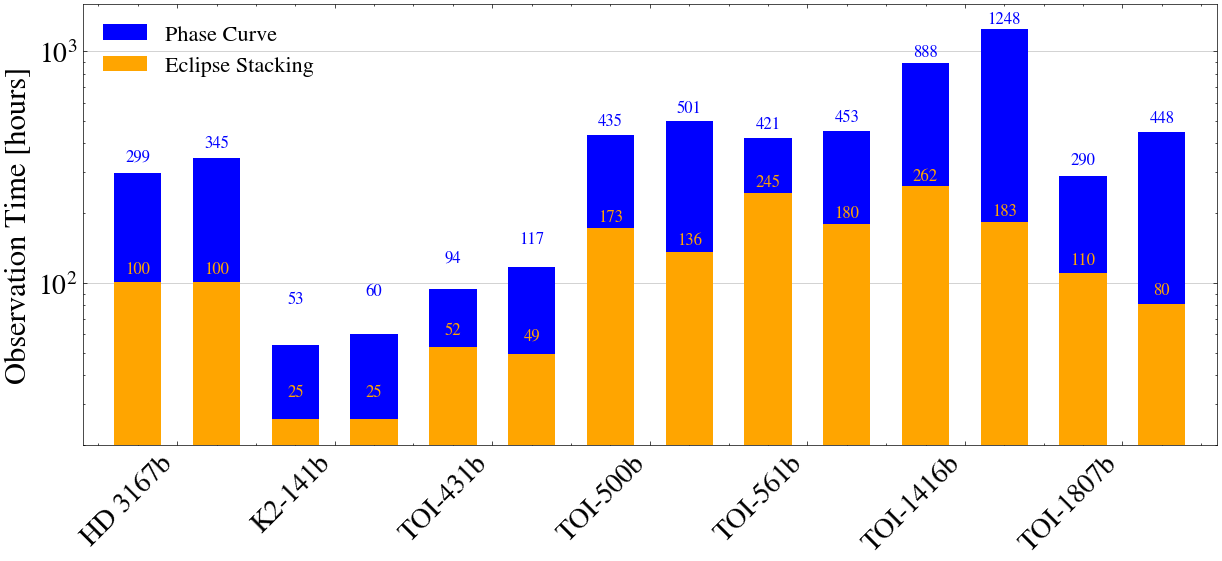

In [14]:
# group bars by planet, in a fixed planet order, sorted by Time within each planet (same ordering as the grouped plots)
planet_order = ["HD 3167b", "K2-141b", "TOI-431b", "TOI-500b", "TOI-561b", "TOI-1416b", "TOI-1807b"]
planet_rank = Planet.map({p: i for i, p in enumerate(planet_order)})
composite = planet_rank.values * 10000 + Time.values
order = np.argsort(composite)
mask = (N_day < 1000) & (N_day > 0) # filter out N_day = 0

N_obs_sorted = N_obs.iloc[order].loc[mask]
N_day_sorted = N_day.iloc[order].loc[mask]
Case_sorted = Case.iloc[order].loc[mask]
Planet_sorted = Planet.iloc[order].loc[mask]
T_day_sorted = T_day.iloc[order].loc[mask]
Time_sorted = Time.iloc[order].loc[mask] # T_obs, aligned to the same cases/order

n_bars = len(Planet_sorted)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * n_bars), 6))
plt.grid(False); plt.grid(True, axis='y')

# draw the larger of the two bars behind, the smaller one in front so both are visible
for i, (t_obs, t_day) in enumerate(zip(Time_sorted, T_day_sorted)):
    if t_day <= t_obs:
        back_val, back_color = t_obs, "blue"
        front_val, front_color = t_day, "orange"
    else:
        back_val, back_color = t_day, "orange"
        front_val, front_color = t_obs, "blue"
    ax.bar(i, back_val, color=back_color, width=0.6, alpha=1, zorder=2)
    ax.bar(i, front_val, color=front_color, width=0.6, alpha=1, zorder=3)

legend_elements = [Patch(facecolor="blue", label="Phase Curve"),
                   Patch(facecolor="orange", label="Eclipse Stacking")]
ax.legend(handles=legend_elements)

# write each bar's own count on top of it, in the bar's color
obs_offset = 0.02 * max(Time_sorted)
day_offset = 0.02 * max(T_day_sorted)
for i, (t_obs, t_day, n_obs, n_day) in enumerate(zip(Time_sorted, T_day_sorted, N_obs_sorted, N_day_sorted)):
    ax.text(i, t_obs + obs_offset, f"{int(t_obs)}", ha="center", va="bottom", color="blue", fontsize=12, zorder=4)
    ax.text(i, t_day + day_offset, f"{int(t_day)}", ha="center", va="bottom", color="orange", fontsize=12, zorder=4)

# one planet label centered between the bars of each group, instead of one label per bar
group_ticks, group_labels = [], []
start = 0
for i in range(1, n_bars + 1):
    if i == n_bars or Planet_sorted.iloc[i] != Planet_sorted.iloc[start]:
        group_ticks.append((start + i - 1) / 2)
        group_labels.append(Planet_sorted.iloc[start])
        start = i

ax.set_ylim(20, 1600)
ax.set_xlim(-0.7, n_bars - 0.3)
ax.set_xticks(group_ticks)
ax.set_xticklabels(group_labels, rotation=45, ha="right")
ax.set_yticks([100, 1000])
ax.set_ylabel("Observation Time [hours]")
ax.set_yscale("log")
#ax.set_xlabel("Planet (Case #)")
#ax.set_title("Number of Observations per Planet/Case")

plt.tight_layout()
plt.savefig("T_day_barplot.pdf", format="pdf", dpi=300)
plt.show()

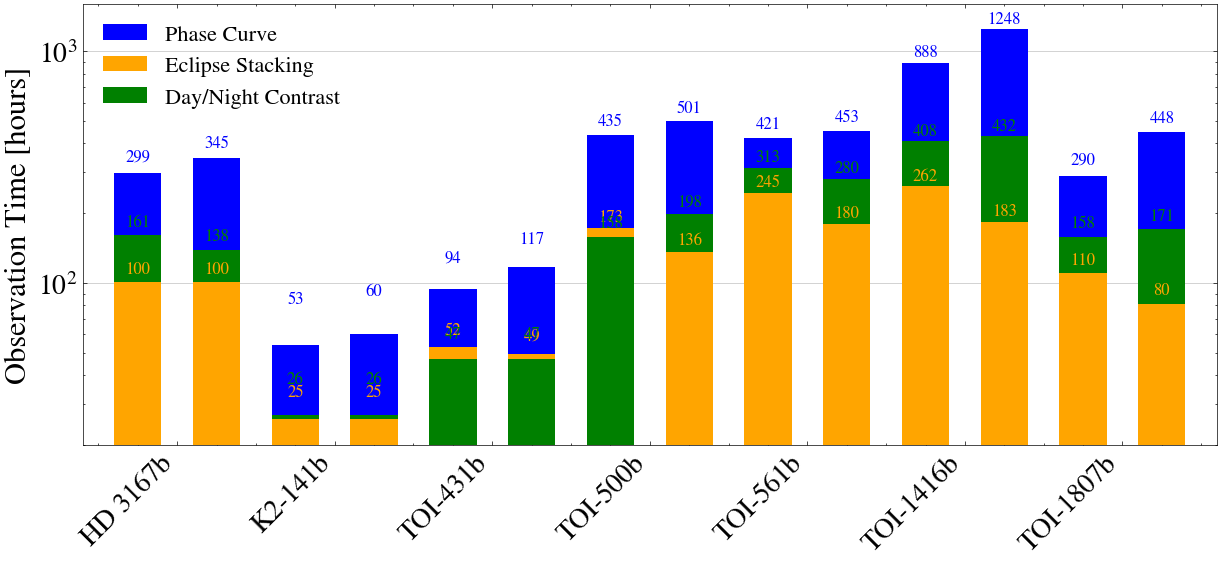

In [16]:
# group bars by planet, in a fixed planet order, sorted by Time within each planet (same ordering as the grouped plots)
planet_order = ["HD 3167b", "K2-141b", "TOI-431b", "TOI-500b", "TOI-561b", "TOI-1416b", "TOI-1807b"]
planet_rank = Planet.map({p: i for i, p in enumerate(planet_order)})
composite = planet_rank.values * 10000 + Time.values
order = np.argsort(composite)
mask = (N_pc < 1000) & (N_pc > 0) # filter out N_pc = 0

N_obs_sorted = N_obs.iloc[order].loc[mask]
N_day_sorted = N_day.iloc[order].loc[mask]
N_pc_sorted = N_pc.iloc[order].loc[mask]
Case_sorted = Case.iloc[order].loc[mask]
Planet_sorted = Planet.iloc[order].loc[mask]
T_pc_sorted = T_pc.iloc[order].loc[mask]
Time_sorted = Time.iloc[order].loc[mask] # T_obs, aligned to the same cases/order
T_day_sorted = T_day.iloc[order].loc[mask] # T_day, aligned to the same cases/order

n_bars = len(Planet_sorted)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * n_bars), 6))
plt.grid(False); plt.grid(True, axis='y')

# draw the largest of the three bars behind, down to the smallest in front so all are visible
for i, (t_obs, t_day, t_pc) in enumerate(zip(Time_sorted, T_day_sorted, T_pc_sorted)):
    bars = sorted([(t_obs, "blue"), (t_day, "orange"), (t_pc, "green")], reverse=True)
    for z, (val, color) in enumerate(bars):
        ax.bar(i, val, color=color, width=0.6, alpha=1, zorder=2 + z)

legend_elements = [Patch(facecolor="blue", label="Phase Curve"),
                   Patch(facecolor="orange", label="Eclipse Stacking"),
                   Patch(facecolor="green", label="Day/Night Contrast")]
ax.legend(handles=legend_elements)

# write each bar's own count on top of it, in the bar's color
obs_offset = 0.02 * max(Time_sorted)
day_offset = 0.02 * max(T_day_sorted)
pc_offset = 0.02 * max(T_pc_sorted)
for i, (t_obs, t_day, t_pc, n_obs, n_day, n_pc) in enumerate(zip(Time_sorted, T_day_sorted, T_pc_sorted, N_obs_sorted, N_day_sorted, N_pc_sorted)):
    ax.text(i, t_obs + obs_offset, f"{int(t_obs)}", ha="center", va="bottom", color="blue", fontsize=12, zorder=5)
    ax.text(i, t_day + day_offset, f"{int(t_day)}", ha="center", va="bottom", color="orange", fontsize=12, zorder=5)
    ax.text(i, t_pc + pc_offset, f"{int(t_pc)}", ha="center", va="bottom", color="green", fontsize=12, zorder=5)

# one planet label centered between the bars of each group, instead of one label per bar
group_ticks, group_labels = [], []
start = 0
for i in range(1, n_bars + 1):
    if i == n_bars or Planet_sorted.iloc[i] != Planet_sorted.iloc[start]:
        group_ticks.append((start + i - 1) / 2)
        group_labels.append(Planet_sorted.iloc[start])
        start = i

ax.set_ylim(20, 1600)
ax.set_xlim(-0.7, n_bars - 0.3)
ax.set_xticks(group_ticks)
ax.set_xticklabels(group_labels, rotation=45, ha="right")
ax.set_yticks([100, 1000])
ax.set_ylabel("Observation Time [hours]")
ax.set_yscale("log")
#ax.set_xlabel("Planet (Case #)")
#ax.set_title("Number of Observations per Planet/Case")

plt.tight_layout()
plt.savefig("T_pc_barplot.pdf", format="pdf", dpi=300)
plt.show()

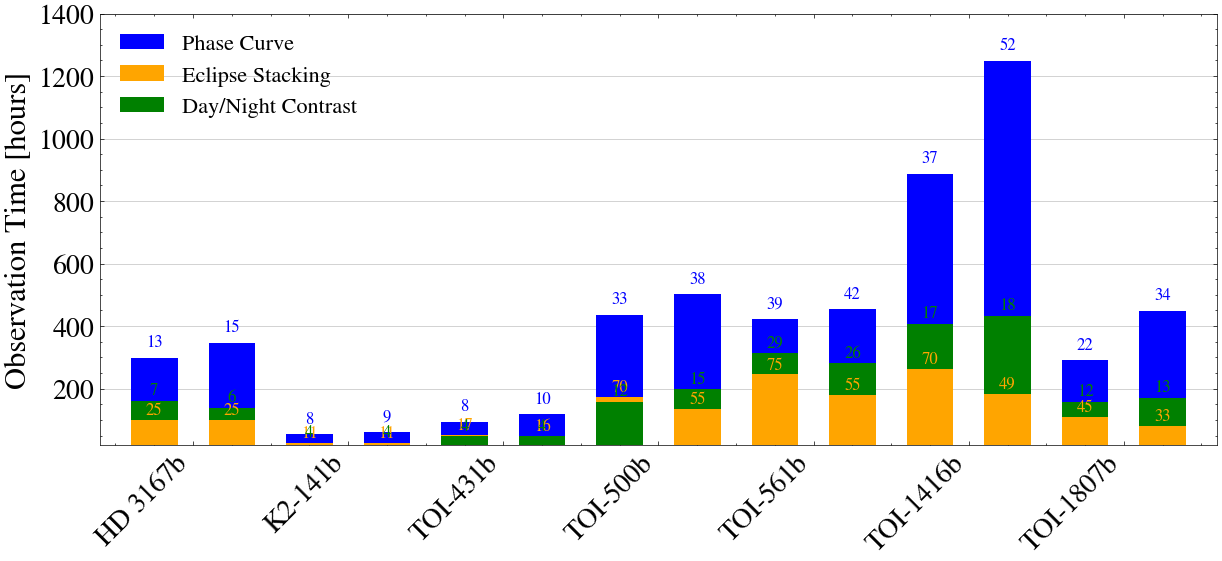

In [19]:
# group bars by planet, in a fixed planet order, sorted by Time within each planet
planet_order = ["HD 3167b", "K2-141b", "TOI-431b", "TOI-500b", "TOI-561b", "TOI-1416b", "TOI-1807b"]
planet_rank = Planet.map({p: i for i, p in enumerate(planet_order)})

mask = (N_pc < 1000) & (N_pc > 0) # filter out N_pc = 0

composite = planet_rank.values * 10000 + Time.values
order = np.argsort(composite)

N_obs_sorted = N_obs.iloc[order].loc[mask]
N_day_sorted = N_day.iloc[order].loc[mask]
N_pc_sorted = N_pc.iloc[order].loc[mask]
Case_sorted = Case.iloc[order].loc[mask]
Planet_sorted = Planet.iloc[order].loc[mask]
T_pc_sorted = T_pc.iloc[order].loc[mask]
Time_sorted = Time.iloc[order].loc[mask] # T_obs, aligned to the same cases/order
T_day_sorted = T_day.iloc[order].loc[mask] # T_day, aligned to the same cases/order

n_bars = len(Planet_sorted)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * n_bars), 6))
plt.grid(False); plt.grid(True, axis='y')

# draw the largest of the three bars behind, down to the smallest in front so all are visible
for i, (t_obs, t_day, t_pc) in enumerate(zip(Time_sorted, T_day_sorted, T_pc_sorted)):
    bars = sorted([(t_obs, "blue"), (t_day, "orange"), (t_pc, "green")], reverse=True)
    for z, (val, color) in enumerate(bars):
        ax.bar(i, val, color=color, width=0.6, alpha=1, zorder=2 + z)

legend_elements = [Patch(facecolor="blue", label="Phase Curve"),
                   Patch(facecolor="orange", label="Eclipse Stacking"),
                   Patch(facecolor="green", label="Day/Night Contrast")]
ax.legend(handles=legend_elements)

# write each bar's own count on top of it, in the bar's color
obs_offset = 0.02 * max(Time_sorted)
day_offset = 0.02 * max(T_day_sorted)
pc_offset = 0.02 * max(T_pc_sorted)
for i, (t_obs, t_day, t_pc, n_obs, n_day, n_pc) in enumerate(zip(Time_sorted, T_day_sorted, T_pc_sorted, N_obs_sorted, N_day_sorted, N_pc_sorted)):
    ax.text(i, t_obs + obs_offset, f"{int(n_obs)}", ha="center", va="bottom", color="blue", fontsize=12, zorder=5)
    ax.text(i, t_day + day_offset, f"{int(n_day)}", ha="center", va="bottom", color="orange", fontsize=12, zorder=5)
    ax.text(i, t_pc + pc_offset, f"{int(n_pc)}", ha="center", va="bottom", color="green", fontsize=12, zorder=5)

# one planet label centered between the bars of each group, instead of one label per bar
group_ticks, group_labels = [], []
start = 0
for i in range(1, n_bars + 1):
    if i == n_bars or Planet_sorted.iloc[i] != Planet_sorted.iloc[start]:
        group_ticks.append((start + i - 1) / 2)
        group_labels.append(Planet_sorted.iloc[start])
        start = i

ax.set_ylim(20, 1400)
ax.set_xlim(-0.7, n_bars - 0.3)
ax.set_xticks(group_ticks)
ax.set_xticklabels(group_labels, rotation=45, ha="right")

ax.set_yticks([100, 1000])
ax.set_ylabel("Observation Time [hours]")
ax.set_yscale("linear")

plt.tight_layout()
plt.savefig("T_grouped_barplot.pdf", format="pdf", dpi=300)
plt.show()

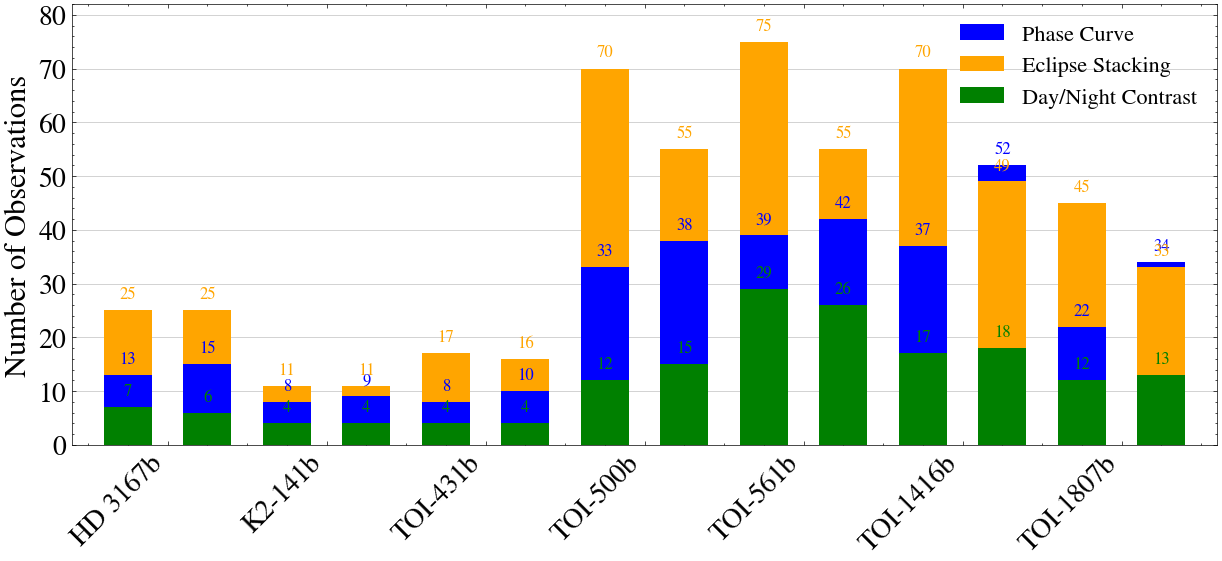

In [21]:
# same grouped ordering as the previous plot, but the y-axis is now the number of observations instead of hours
planet_order = ["HD 3167b", "K2-141b", "TOI-431b", "TOI-500b", "TOI-561b", "TOI-1416b", "TOI-1807b"]
planet_rank = Planet.map({p: i for i, p in enumerate(planet_order)})

mask = (N_pc < 1000) & (N_pc > 0) # filter out N_pc = 0

composite = planet_rank.values * 10000 + Time.values
order = np.argsort(composite)

N_obs_sorted = N_obs.iloc[order].loc[mask]
N_pc_sorted = N_pc.iloc[order].loc[mask]
N_day_sorted = N_day.iloc[order].loc[mask]
Case_sorted = Case.iloc[order].loc[mask]
Planet_sorted = Planet.iloc[order].loc[mask]

n_bars = len(Planet_sorted)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * n_bars), 6))
plt.grid(False); plt.grid(True, axis='y')

# phase curve and day/night contrast both use the number of phase curves, eclipse stacking uses the number of eclipses
# draw the larger of the two values behind, the smaller one in front so both are visible
for i, (n_obs, n_pc, n_day) in enumerate(zip(N_obs_sorted, N_pc_sorted, N_day_sorted)):
    bars = sorted([(n_obs, "blue"), (n_day, "orange"), (n_pc, "green")], reverse=True)
    for z, (val, color) in enumerate(bars):
        ax.bar(i, val, color=color, width=0.6, alpha=1, zorder=2 + z)

legend_elements = [Patch(facecolor="blue", label="Phase Curve"),
                   Patch(facecolor="orange", label="Eclipse Stacking"),
                   Patch(facecolor="green", label="Day/Night Contrast")]
ax.legend(handles=legend_elements)

# write each bar's own count on top of it, in the bar's color
label_offset = 1.5
for i, (n_obs, n_pc, n_day) in enumerate(zip(N_obs_sorted, N_pc_sorted, N_day_sorted)):
    ax.text(i, n_obs + label_offset, f"{int(n_obs)}", ha="center", va="bottom", color="blue", fontsize=12, zorder=6)
    ax.text(i, n_day + label_offset, f"{int(n_day)}", ha="center", va="bottom", color="orange", fontsize=12, zorder=6)
    ax.text(i, n_pc + label_offset, f"{int(n_pc)}", ha="center", va="bottom", color="green", fontsize=12, zorder=6)

# one planet label centered between the bars of each group, instead of one label per bar
group_ticks, group_labels = [], []
start = 0
for i in range(1, n_bars + 1):
    if i == n_bars or Planet_sorted.iloc[i] != Planet_sorted.iloc[start]:
        group_ticks.append((start + i - 1) / 2)
        group_labels.append(Planet_sorted.iloc[start])
        start = i

ax.set_ylim(0, 82)
ax.set_xlim(-0.7, n_bars - 0.3)
ax.set_yticks(np.arange(0, 81, step=10))

# planet names directly on the main axis, centered on each group
ax.set_xticks(group_ticks)
ax.set_xticklabels(group_labels, rotation=45, ha="right")

ax.set_ylabel("Number of Observations")

plt.tight_layout()
plt.savefig("N_grouped_barplot.pdf", format="pdf", dpi=300)
plt.show()